In [25]:
import numpy as np
import matplotlib.pyplot as plt
import PcmPy as pcm
from pathlib import Path
import sys
import os

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl
plt.style.use('default')

# MDS projections of BOLD activity

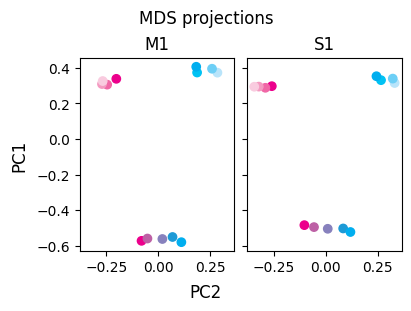

In [26]:
H = 'L'

rois = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(4, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(ROOT, 'data', 'encoding', f'G_obs.plan-exec.glm12.{H}.{roi}.npy'))
    G = G.mean(axis=0)
    mds, _ = pcm.classical_mds(G)
    ax.scatter(mds[:, 1], mds[:, 0], color=list(gl.colour_mapping.values()))
    ax.set_title(roi)

fig.supxlabel('PC2')
fig.supylabel('PC1')
fig.suptitle('MDS projections')

plt.show()

# EMG projection onto first two principal components (Fig. 8b)

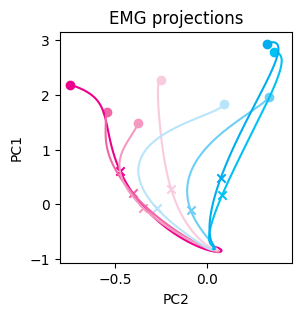

In [29]:
pcs = np.load(os.path.join(ROOT, 'data', 'behavioural', f'trajectories.npy'))
tAx = np.linspace(-1, 2, 3 * gl.fsample_emg)
pcs = pcs.mean(axis=0)
pcs[:, 1] = pcs[:, 1] * -1 # keep index on the left to match BOLD MDS proj visually
idx100, idx200 = np.where(tAx <=.1)[0][-1], np.where(tAx <=.2)[0][-1]
pcs100 = pcs[..., idx100]
pcs200 = pcs[..., idx200]
pcs = pcs[..., (tAx>-.02) & (tAx<.2)]
colour = list(gl.colour_mapping.values())[5:]

fig, ax = plt.subplots(figsize=(3, 3))

for cond in range(pcs.shape[0]):
    ax.scatter(pcs200[cond, 1], pcs200[cond, 0], color=colour[cond], marker='o')
    ax.scatter(pcs100[cond, 1], pcs100[cond, 0], color=colour[cond], marker='x')
    ax.plot(pcs[cond, 1], pcs[cond, 0], color=colour[cond])

ax.set_title('EMG projections')
ax.set_xlabel('PC2')
ax.set_ylabel('PC1')

plt.show()
